[Home](../../README.md)

### Model Evaluation

This is a demonstration of evaluating a model.

#### Step 1

Load the required dependencies.


In [63]:
# Import frameworks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('../../style_Matplotlib_charts.mplstyle')
from sklearn.linear_model import LinearRegression
import pickle

####  Step 2

Load the model for testing

In [64]:
filename = 'my_saved_model_v1.sav'
model_A = pickle.load(open(filename, 'rb'))

(Optional) Load a second model if you want to do comparative testing

In [65]:
# filename = 'my_saved_model_v1.sav'
# model_B = pickle.load(open(filename, 'rb'))

####  Step 3
Open and parse the test data CSV file and store the data as variable array data objects.

In [66]:
x_col = 'km_from_cbd'
testing_data = pd.read_csv('2.4.1.testing_data.csv')
x_test = np.array(testing_data[x_col]).reshape(-1,1)
y_test = np.array(testing_data['price'])

#### Step 5

Plot the test data features, targets and linear regression model to visually evaluate the model.

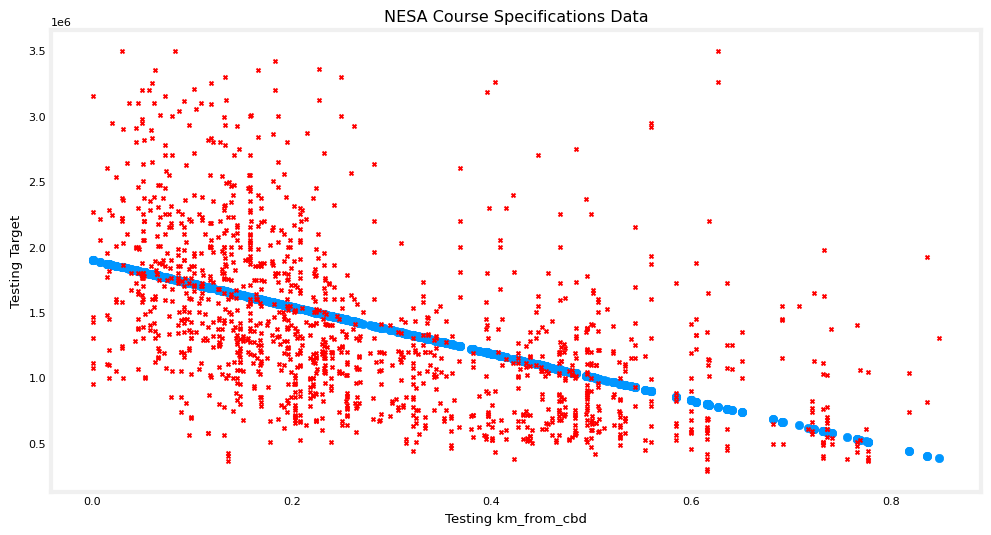

In [67]:
y_pred = model_A.predict(x_test)
plt.figure(figsize=(12, 6))
plt.scatter(x_test, y_pred)
plt.scatter(x_test, y_test, marker='x', c='r', s=1)
plt.title("NESA Course Specifications Data")
plt.xlabel(f'Testing {x_col}')
plt.ylabel(f'Testing Target')
plt.show()

#### Step 6

Use the 'score' method of the `LinearRegression` class to return a score based evaluation of the models accuracy or performance.

In [68]:
test_score = model_A.score(x_test, y_test)
print(f'Training data score: {test_score}')

Training data score: 0.24976403225706012


#### Step 7

Manually calculate and evaluate the 'loss' and 'cost' of the model using the test data.

In [69]:
table = pd.DataFrame({
    testing_data.columns[0]: x_test.flatten(),  # Flatten x for easy display
    testing_data.columns[1]: y_test,
    'Predicted result':model_A.predict(x_test),
    'Loss' : abs(model_A.predict(x_test).round(2) - y_test)**2
})
print(table)
cost = 1 / (2 * table.shape[0]) * table['Loss'].sum()

print(f"The cost or average loss of this model is {cost}")

         price  num_bath  Predicted result          Loss
0     0.304156    840000      1.355438e+06  2.656759e+11
1     0.617727   2200000      7.950400e+05  1.973912e+12
2     0.097646   1365000      1.724502e+06  1.292415e+11
3     0.169654   1200000      1.595813e+06  1.566676e+11
4     0.199399    850000      1.542654e+06  4.797701e+11
...        ...       ...               ...           ...
1351  0.495744   1215900      1.013042e+06  4.115135e+10
1352  0.233050   1150000      1.482516e+06  1.105669e+11
1353  0.316475   1200000      1.333423e+06  1.780160e+10
1354  0.483425    720000      1.035057e+06  9.926093e+10
1355  0.221733   1400000      1.502741e+06  1.055573e+10

[1356 rows x 4 columns]
The cost or average loss of this model is 156989881212.26776


You may want to do some manual predictions to understand your model.

In [70]:
print(model_A.predict([[0.1]]))
print(model_A.predict([[1]]))

[1720295.6171842]
[111859.75654807]


#### Step 8

Evaluate the X axis intercept and gradient or coefficient of your model by using the getter methods to return the intercept and coefficient from my_model() object.

In [71]:
print(f'X Axis intercept: {model_A.intercept_}')
print(f'Coefficient: {model_A.coef_}')

X Axis intercept: 1899010.712810433
Coefficient: [-1787150.95626237]


#### Step 9. Multiple Variable Linear Regression

You should be able to understand the code snippets with less guidelines.

In [72]:
filename = 'my_saved_model_v2.sav'
model_C = pickle.load(open(filename, 'rb'))

In [73]:
mx_col = ["km_from_cbd", "suburb_sqkm"]
testing_data = pd.read_csv('2.4.1.testing_data.csv')
mx_test = np.array(testing_data[mx_col])
my_test = np.array(testing_data['price'])

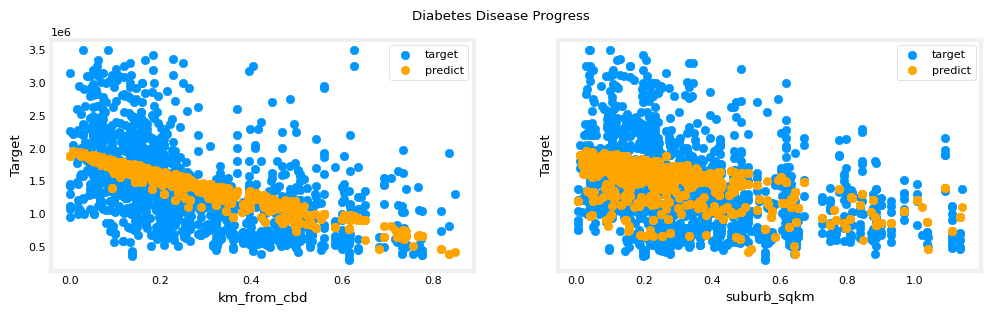

In [74]:
my_pred = model_C.predict(mx_test)

# plot predictions and targets vs original features    
fig,ax=plt.subplots(1,len(mx_col),figsize=(12,3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(mx_test[:,i],my_test, label = 'target')
    ax[i].set_xlabel(mx_col[i])
    ax[i].scatter(mx_test[:,i],my_pred,color="orange", label = 'predict')
    ax[i].set_ylabel("Target"); ax[i].legend();
fig.suptitle("Diabetes Disease Progress")
plt.show()

In [75]:
test_score = model_C.score(mx_test, my_test)
print(f'Training data score: {test_score}')

Training data score: 0.2811050853975271


In [76]:
print(model_C.predict([[0.1,0.1]]))
print(model_C.predict([[1,0.5]]))

[1786911.794864]
[177138.42749612]


In [77]:
data = {col: mx_test[:, i] for i, col in enumerate(mx_col)}
data['Target'] = my_test
data['Predicted result'] = model_C.predict(mx_test)
data['Loss'] = abs(model_C.predict(mx_test).round(2) - my_test)**2
table = pd.DataFrame(data)

cost = 1 / (2 * table.shape[0]) * table['Loss'].sum()
print(f"The cost or average loss of this model is {cost}")

print(table)

The cost or average loss of this model is 150431640222.46008
      km_from_cbd  suburb_sqkm   Target  Predicted result          Loss
0        0.304156     0.641279   840000      1.235682e+06  1.565646e+11
1        0.617727     0.045662  2200000      9.783562e+05  1.492414e+12
2        0.097646     0.217808  1365000      1.742036e+06  1.421563e+11
3        0.169654     0.146484  1200000      1.655913e+06  2.078566e+11
4        0.199399     0.171781   850000      1.597723e+06  5.590897e+11
...           ...          ...      ...               ...           ...
1351     0.495744     0.884932  1215900      8.275425e+05  1.508216e+11
1352     0.233050     0.428219  1150000      1.437805e+06  8.283199e+10
1353     0.316475     0.289041  1200000      1.361380e+06  2.604335e+10
1354     0.483425     0.767580   720000      8.957794e+05  3.089838e+10
1355     0.221733     0.194977  1400000      1.552296e+06  2.319408e+10

[1356 rows x 5 columns]


In [78]:
print(f'X Axis intercept: {model_C.intercept_}')
print(f'Coefficient: {model_C.coef_}')

X Axis intercept: 1988719.201903585
Coefficient: [-1605087.47841911  -412986.5919767 ]


#### Step 10. Polynomial Linear Regression

You should be able to understand the code snippets with less guidelines.

In [79]:
model_filename = 'my_saved_model_v3.sav'
poly_filename = 'my_saved_poly_v3.pkl'

model_D = pickle.load(open(model_filename, 'rb'))
poly = pickle.load(open(poly_filename, 'rb'))

In [80]:
mx_col = ['km_from_cbd']
testing_data = pd.read_csv('2.4.1.testing_data.csv')
mx_test = np.array(testing_data[mx_col])
my_test = np.array(testing_data['price'])

In [81]:
poly_features = poly.fit_transform(mx_test)

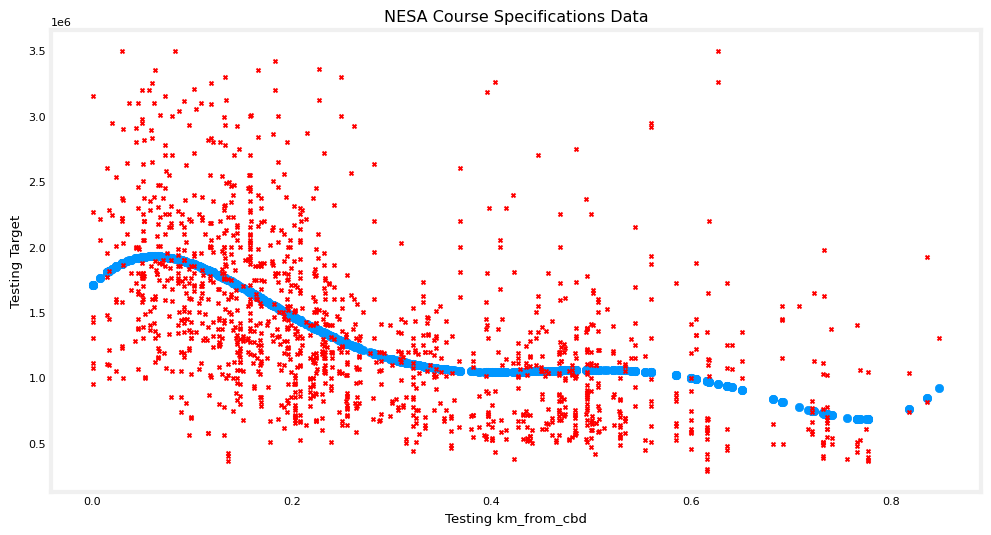

In [82]:
y_pred = model_D.predict(poly_features)

plt.figure(figsize=(12, 6))
plt.scatter(x_test, y_pred)
plt.scatter(x_test, y_test, marker='x', c='r', s=1)
plt.title("NESA Course Specifications Data")
plt.xlabel(f'Testing {x_col}')
plt.ylabel(f'Testing Target')
plt.show()

In [83]:
test_score = model_D.score(poly_features, my_test)
print(f'Training data score: {test_score}')

Training data score: 0.2941446909073354


In [84]:
new_poly_feature = poly.fit_transform([[0.1]])
print(model_D.predict(new_poly_feature))

[1872385.08942293]


In [85]:
data = {col: mx_test[:, i] for i, col in enumerate(mx_col)}
data['Target'] = my_test
data['Predicted result'] = model_D.predict(poly_features)
data['Loss'] = abs(model_D.predict(poly_features).round(2) - my_test)**2
table = pd.DataFrame(data)

cost = 1 / (2 * table.shape[0]) * table['Loss'].sum()
print(f"The cost or average loss of this model is {cost}")

print(table)

The cost or average loss of this model is 147703050574.51556
      km_from_cbd   Target  Predicted result          Loss
0        0.304156   840000      1.133457e+06  8.611716e+10
1        0.617727  2200000      9.689895e+05  1.515387e+12
2        0.097646  1365000      1.878597e+06  2.637821e+11
3        0.169654  1200000      1.604755e+06  1.638269e+11
4        0.199399   850000      1.474876e+06  3.904700e+11
...           ...      ...               ...           ...
1351     0.495744  1215900      1.059524e+06  2.445357e+10
1352     0.233050  1150000      1.339516e+06  3.591626e+10
1353     0.316475  1200000      1.110651e+06  7.983237e+09
1354     0.483425   720000      1.057891e+06  1.141702e+11
1355     0.221733  1400000      1.382953e+06  2.906101e+08

[1356 rows x 4 columns]


#### Step 11

When your model is ready for operations, move it to the [3.Operations\3.1.Deploy_Model](\3.Operations\3.1.Deploy_Model) folder.